# File handling in CAMAT

CAMAT analyzes **MEI**. Convert other encodings to MEI first, then call `parse_files(...)`.
Verovio always produces that analysis MEI. The steps before Verovio depend on the source.

![CAMAT conversion routes to MEI](../docs/assets/format-conversion.svg)

This notebook uses tiny in-memory examples, the MEI file bundled with the package, and one optional internet example. It does not import `scripts/`.

Docs page: `docs/guides/formats.md`.

In [1]:
from contextlib import ExitStack
from importlib.resources import as_file, files
from pathlib import Path
import os
import shutil
import sys
import tempfile

from IPython.display import display

# This notebook lives in notebooks/, so cwd is not the repo root.
_here = Path.cwd().resolve()
_root = next(
    (p for p in (_here, *_here.parents) if (p / "camat" / "__init__.py").is_file()),
    None,
)
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from camat import (
    __version__,
    parse_files,
    vrv_convert_to_mei,
    vrv_display_svg,
    vrv_guess_input_from,
    vrv_quiet,
    vrv_render_page,
    vrv_set_options,
)

WORK = Path(tempfile.mkdtemp(prefix="camat_formats_"))
_RESOURCE_STACK = ExitStack()
PACKAGED_MEI = _RESOURCE_STACK.enter_context(
    as_file(files("camat").joinpath("examples", "duration_semantics.mei"))
)

print("CAMAT:", __version__)
print("Work dir:", WORK)
print("Packaged MEI:", PACKAGED_MEI)

CAMAT: 0.1.13
Work dir: /tmp/camat_formats_iwve3lln
Packaged MEI: /home/eggi/Nextcloud/code/public_repos/camat_v2/camat/examples/duration_semantics.mei


## Already MEI: parse directly

If the source is common-notation MEI, skip conversion. `parse_files(...)` defaults to the Verovio backend.

In [2]:
results, dfs_by_name, df_pitch = parse_files(
    [str(PACKAGED_MEI)],
    quiet_native_warnings=True,
    print_parsed_summary=True,
    backend="none",
    include_xml_ids=True,
    n_jobs=1,
)

display(df_pitch.head())

Processing (verovio): duration_semantics.mei -> 00_duration_semantics
Extracted non-barline MEI events: 9 event(s), types=['bend', 'measure', 'slur', 'tie', 'tuplet_span'].


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI,Voice,xml_id,grace,tied,slurred,tuplet,fermata,articulations,ornaments,technical,Logical Duration,Performed Duration
0,1,0.000,0.000,1.500,C4,60,P1 - Voice 1,dotted,<NA>,NaN,start,NaN,True,NaN,trill,bend,1.500,<NA>
1,1,1.500,1.500,0.333,D4,62,P1 - Voice 1,triplet-1,<NA>,NaN,stop,member,<NA>,stacc,NaN,NaN,0.333,<NA>
2,1,1.833,1.833,0.333,E4,64,P1 - Voice 1,triplet-2,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.333,<NA>
3,1,2.167,2.167,0.333,F4,65,P1 - Voice 1,triplet-3,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.333,<NA>
4,1,2.500,2.500,1.500,A4,69,P1 - Voice 1,measure-1-tail,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,1.500,<NA>
5,2,0.000,4.000,0.300,G4,67,P1 - Voice 1,quintuplet-1,<NA>,NaN,NaN,start,<NA>,NaN,NaN,NaN,0.300,<NA>
6,2,0.300,4.300,0.300,A4,69,P1 - Voice 1,quintuplet-2,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.300,<NA>
7,2,0.600,4.600,0.300,B4,71,P1 - Voice 1,quintuplet-3,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.300,<NA>
8,2,0.900,4.900,0.300,C5,72,P1 - Voice 1,quintuplet-4,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.300,<NA>
9,2,1.200,5.200,0.300,D5,74,P1 - Voice 1,quintuplet-5,<NA>,NaN,NaN,stop,<NA>,NaN,NaN,NaN,0.300,<NA>


Rows: 12, unique pitches: 11


,type,subtype,Measure,Local Onset,Global Onset,Duration,Voice,xml_id,start_xml_id,end_xml_id,...,wordpos,con,mm,mm_unit,mm_dots,measure_type,measure_metcon,measure_join,measure_n,extra
0,measure,<NA>,1,0.00,0.00,4.000,NaN,duration-measure-1,NaN,NaN,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>
1,bend,<NA>,1,0.00,0.00,0.000,P1 - Voice 1,NaN,dotted,NaN,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>
2,slur,<NA>,1,0.00,0.00,1.833,NaN,NaN,dotted,triplet-1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>
3,measure,<NA>,2,0.00,4.00,4.000,NaN,duration-measure-2,NaN,NaN,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>
4,tuplet_span,<NA>,2,0.00,4.00,1.500,NaN,NaN,quintuplet-1,quintuplet-5,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,{'numbase': '3'}
5,rest,rest,2,1.50,5.50,2.000,P1 - Voice 1,measure-2-rest-half,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
6,rest,rest,2,3.50,7.50,0.500,P1 - Voice 1,measure-2-rest-eighth,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
7,measure,<NA>,3,0.00,8.00,4.000,NaN,duration-measure-3,NaN,NaN,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,<NA>
8,tie,<NA>,3,0.00,8.00,0.000,NaN,NaN,tie-a,tie-b,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,<NA>
9,rest,rest,3,2.25,10.25,1.500,P1 - Voice 1,measure-3-tail,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


Event rows: 12

Parsed DataFrames:
- 00_duration_semantics: rows=12, unique_pitches=11, min_duration=0.3, voices=1 (['P1 - Voice 1'])


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI,Voice,xml_id,grace,tied,slurred,tuplet,fermata,articulations,ornaments,technical,Logical Duration,Performed Duration
0,1,0.000,0.000,1.500,C4,60,P1 - Voice 1,dotted,<NA>,NaN,start,NaN,True,NaN,trill,bend,1.500,<NA>
1,1,1.500,1.500,0.333,D4,62,P1 - Voice 1,triplet-1,<NA>,NaN,stop,member,<NA>,stacc,NaN,NaN,0.333,<NA>
2,1,1.833,1.833,0.333,E4,64,P1 - Voice 1,triplet-2,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.333,<NA>
3,1,2.167,2.167,0.333,F4,65,P1 - Voice 1,triplet-3,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.333,<NA>
4,1,2.500,2.500,1.500,A4,69,P1 - Voice 1,measure-1-tail,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,1.500,<NA>


## Verovio-native formats

`vrv_guess_input_from(...)` inspects the suffix or contents. `vrv_convert_to_mei(...)` loads that source into Verovio and returns MEI. Write the string to a `.mei` file before parsing.

Native inputs include MusicXML / `.mxl`, Humdrum, ABC, PAE, DARMS, EsAC, and Volpiano. `.xml` is sniffed as MEI or MusicXML from the contents.

In [3]:
MUSICXML = '''<?xml version="1.0" encoding="UTF-8" standalone="no"?>
<!DOCTYPE score-partwise PUBLIC "-//Recordare//DTD MusicXML 4.0 Partwise//EN" "http://www.musicxml.org/dtds/partwise.dtd">
<score-partwise version="4.0">
  <work><work-title>CAMAT formats tutorial</work-title></work>
  <part-list>
    <score-part id="P1"><part-name>Music</part-name></score-part>
  </part-list>
  <part id="P1">
    <measure number="1">
      <attributes>
        <divisions>1</divisions>
        <key><fifths>0</fifths></key>
        <time><beats>4</beats><beat-type>4</beat-type></time>
        <clef><sign>G</sign><line>2</line></clef>
      </attributes>
      <note><pitch><step>C</step><octave>4</octave></pitch><duration>1</duration><type>quarter</type></note>
      <note><pitch><step>D</step><octave>4</octave></pitch><duration>1</duration><type>quarter</type></note>
      <note><pitch><step>E</step><octave>4</octave></pitch><duration>1</duration><type>quarter</type></note>
      <note><pitch><step>F</step><octave>4</octave></pitch><duration>1</duration><type>quarter</type></note>
    </measure>
  </part>
</score-partwise>
'''

KERN = "\n".join(
    ["**kern", "*clefG2", "*k[]", "*M4/4", "4c", "4d", "4e", "4f", "*-"]
) + "\n"

musicxml_path = WORK / "tiny.musicxml"
kern_path = WORK / "tiny.krn"
musicxml_path.write_text(MUSICXML, encoding="utf-8")
kern_path.write_text(KERN, encoding="utf-8")

for path in (musicxml_path, kern_path):
    print(path.name, "->", vrv_guess_input_from(str(path), path.read_text(encoding="utf-8")))

tiny.musicxml -> musicxml
tiny.krn -> humdrum


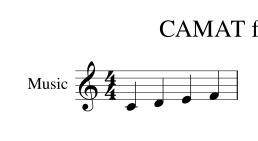

tiny.musicxml -> tiny_from_musicxml.mei (2954 chars)


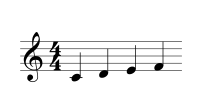

tiny.krn -> tiny_from_kern.mei (2506 chars)


In [4]:
def convert_and_preview(source: Path, label: str) -> Path:
    with vrv_quiet():
        vrv_set_options(
            pageWidth=1400,
            pageHeight=400,
            scale=40,
            breaks="none",
            removeIds=False,
        )
        mei_text = vrv_convert_to_mei(str(source))
        vrv_display_svg(vrv_render_page(1))
    out = WORK / f"{source.stem}_{label}.mei"
    out.write_text(mei_text, encoding="utf-8")
    print(f"{source.name} -> {out.name} ({len(mei_text)} chars)")
    return out

mei_from_musicxml = convert_and_preview(musicxml_path, "from_musicxml")
mei_from_kern = convert_and_preview(kern_path, "from_kern")

## A Verovio-native score from the internet

For a remote score, pass the raw file URL and set `is_url=True`. This example uses chorale 1 from Craig Stuart Sapp's [Bach 370 Chorales](https://github.com/craigsapp/bach-370-chorales) edition, licensed [CC BY-NC-SA 4.0](https://github.com/craigsapp/bach-370-chorales/blob/main/LICENSE.txt). The commit-pinned URL keeps the tutorial reproducible.

Set `CAMAT_RUN_NETWORK_EXAMPLES=0` before starting Jupyter to skip the download. A network failure skips only this example; the local tutorial continues. The converted score is temporary and is not added to the repository.

In [5]:
BACH_CHORALE_URL = (
    "https://raw.githubusercontent.com/craigsapp/bach-370-chorales/"
    "0fd9e00542445a522c6030c80c687b874aa569d5/kern/chor001.krn"
)
RUN_NETWORK_EXAMPLE = os.environ.get("CAMAT_RUN_NETWORK_EXAMPLES", "1").lower() not in {
    "0", "false", "no"
}
remote_mei_path = None

if not RUN_NETWORK_EXAMPLE:
    print("Remote example skipped (CAMAT_RUN_NETWORK_EXAMPLES=0).")
else:
    try:
        with vrv_quiet():
            remote_mei = vrv_convert_to_mei(
                BACH_CHORALE_URL,
                is_url=True,
                timeout=30,
            )
        remote_mei_path = WORK / "bach_chor001.mei"
        remote_mei_path.write_text(remote_mei, encoding="utf-8")
        print("Remote Humdrum ->", remote_mei_path.name, f"({len(remote_mei)} chars)")
    except Exception as exc:
        print(f"Remote example unavailable: {type(exc).__name__}: {exc}")

Remote Humdrum -> bach_chor001.mei (67353 chars)


## music21 bridge (MIDI and other non-Verovio formats)

If Verovio cannot load the source, import it with music21, export MusicXML, then convert that MusicXML with Verovio. MIDI is the usual example: music21 quantizes and respells, so treat the MEI as an import, not as a lossless copy.

MIDI guessed as: None
music21 MusicXML: tiny_from_midi.musicxml


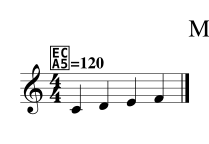

tiny_from_midi.musicxml -> tiny_from_midi_from_midi.mei (3325 chars)


In [6]:
from music21 import converter, meter, note, stream

part = stream.Part()
part.append(meter.TimeSignature("4/4"))
for name in ("C4", "D4", "E4", "F4"):
    part.append(note.Note(name, quarterLength=1))

midi_path = Path(part.write("midi", fp=str(WORK / "tiny.mid")))
print("MIDI guessed as:", vrv_guess_input_from(str(midi_path)))

imported = converter.parse(str(midi_path))
musicxml_from_midi = Path(imported.write("musicxml", fp=str(WORK / "tiny_from_midi.musicxml")))
print("music21 MusicXML:", musicxml_from_midi.name)

mei_from_midi = convert_and_preview(musicxml_from_midi, "from_midi")

## MuseScore files

`.mscz` / `.mscx` are not Verovio inputs. Export MusicXML with MuseScore Studio or `mscore`, then convert with `vrv_convert_to_mei(...)`.

The cell below writes a tiny `.mscx` (C–D–E–F, same as the MusicXML example). If MuseScore is on `PATH` or `MUSESCORE_BIN` is set, it exports MusicXML and converts to MEI. Without MuseScore, convert the file in the editor first.

Wrote tiny.mscx guessed as: None
MuseScore CLI: /usr/bin/mscore
tiny.mscx -> tiny_from_mscx.musicxml


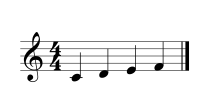

tiny_from_mscx.musicxml -> tiny_from_mscx_from_mscx.mei (3161 chars)


In [7]:
import os
import subprocess

MSCX = """<?xml version="1.0" encoding="UTF-8"?>
<museScore version="4.70">
  <Score>
    <Division>480</Division>
    <Part id="1">
      <Staff>
        <StaffType group="pitched">
          <name>stdNormal</name>
        </StaffType>
      </Staff>
      <trackName>Music</trackName>
      <Instrument id="piano">
        <longName>Piano</longName>
        <shortName>Pno.</shortName>
        <trackName>Piano</trackName>
        <instrumentId>keyboard.piano</instrumentId>
        <Channel>
          <program value="0"/>
        </Channel>
      </Instrument>
    </Part>
    <Staff id="1">
      <Measure>
        <voice>
          <Clef>
            <concertClefType>G</concertClefType>
            <transposingClefType>G</transposingClefType>
          </Clef>
          <TimeSig>
            <sigN>4</sigN>
            <sigD>4</sigD>
          </TimeSig>
          <Chord>
            <durationType>quarter</durationType>
            <Note><pitch>60</pitch><tpc>14</tpc></Note>
          </Chord>
          <Chord>
            <durationType>quarter</durationType>
            <Note><pitch>62</pitch><tpc>16</tpc></Note>
          </Chord>
          <Chord>
            <durationType>quarter</durationType>
            <Note><pitch>64</pitch><tpc>18</tpc></Note>
          </Chord>
          <Chord>
            <durationType>quarter</durationType>
            <Note><pitch>65</pitch><tpc>13</tpc></Note>
          </Chord>
        </voice>
      </Measure>
    </Staff>
  </Score>
</museScore>
"""

mscx_path = WORK / "tiny.mscx"
mscx_path.write_text(MSCX, encoding="utf-8")
print("Wrote", mscx_path.name, "guessed as:", vrv_guess_input_from(str(mscx_path)))

candidates = [
    os.environ.get("MUSESCORE_BIN"),
    "musescore4",
    "mscore4",
    "musescore",
    "mscore",
    "MuseScore-Studio",
]
musescore = next((shutil.which(c) for c in candidates if c and shutil.which(c)), None)
mei_from_mscx = None

if not musescore:
    print(
        "MuseScore CLI not found. Convert .mscz/.mscx to MusicXML or MEI in MuseScore, "
        "or set MUSESCORE_BIN to the mscore binary."
    )
else:
    musicxml_from_mscx = WORK / "tiny_from_mscx.musicxml"
    env = {**os.environ, "QT_QPA_PLATFORM": os.environ.get("QT_QPA_PLATFORM", "offscreen")}
    proc = subprocess.run(
        [musescore, "-f", "-o", str(musicxml_from_mscx), str(mscx_path)],
        capture_output=True,
        text=True,
        env=env,
        check=False,
    )
    if proc.returncode != 0 or not musicxml_from_mscx.exists():
        raise RuntimeError(
            f"MuseScore export failed (returncode={proc.returncode}): "
            f"{(proc.stderr or proc.stdout or '').strip() or musescore}"
        )
    print("MuseScore CLI:", musescore)
    print(mscx_path.name, "->", musicxml_from_mscx.name)
    mei_from_mscx = convert_and_preview(musicxml_from_mscx, "from_mscx")

## Parse the converted MEI

Always parse the `.mei` file, not the MusicXML, Kern, or MIDI source. Generated `xml:id` values are stable for a fixed Verovio version and options; keep the original source next to the MEI.

In [8]:
converted = [mei_from_musicxml, mei_from_kern, mei_from_midi]
if mei_from_mscx is not None:
    converted.append(mei_from_mscx)
if remote_mei_path is not None:
    converted.append(remote_mei_path)

results, dfs_by_name, last_df = parse_files(
    [str(path) for path in converted],
    quiet_native_warnings=True,
    print_parsed_summary=True,
    backend="none",
    include_xml_ids=True,
    n_jobs=1,
)

for name, df in dfs_by_name.items():
    print(name, "rows:", len(df), "xml_id:", "xml_id" in df.columns)
    display(df.head(4))

Parsing files:   0%|          | 0/5 [00:00<?, ?file/s]

Processing (verovio): tiny_from_musicxml.mei -> 00_tiny_from_musicxml
Extracted non-barline MEI events: 4 event(s), types=['clef', 'key_sig', 'measure', 'meter_sig'].


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI,Voice,xml_id,grace,tied,slurred,tuplet,fermata,articulations,ornaments,technical,Logical Duration,Performed Duration
0,1,0.0,0.0,1.0,C4,60,Music - Voice 1,lix0yeh,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
1,1,1.0,1.0,1.0,D4,62,Music - Voice 1,nbwhwcc,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
2,1,2.0,2.0,1.0,E4,64,Music - Voice 1,p7673tv,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
3,1,3.0,3.0,1.0,F4,65,Music - Voice 1,r47av4u,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>


Rows: 4, unique pitches: 4


,type,subtype,Measure,Local Onset,Global Onset,Duration,Voice,xml_id,start_xml_id,end_xml_id,...,wordpos,con,mm,mm_unit,mm_dots,measure_type,measure_metcon,measure_join,measure_n,extra
0,measure,NaN,1.0,0.0,0.0,0.0,NaN,a1ibbfi3,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>
1,clef,G-2,NaN,NaN,NaN,0.0,Music - Voice 1,xr5om3j,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>
2,key_sig,0,NaN,NaN,NaN,0.0,Music - Voice 1,y1hnp8dk,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>
3,meter_sig,4/4,NaN,NaN,NaN,0.0,Music - Voice 1,zkuxju,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>


...

,type,subtype,Measure,Local Onset,Global Onset,Duration,Voice,xml_id,start_xml_id,end_xml_id,...,wordpos,con,mm,mm_unit,mm_dots,measure_type,measure_metcon,measure_join,measure_n,extra
0,measure,NaN,1.0,0.0,0.0,0.0,NaN,h12ynph6,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>
1,clef,G-2,NaN,NaN,NaN,0.0,P1 - Voice 1,eosw86h,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>
2,key_sig,0,NaN,NaN,NaN,0.0,P1 - Voice 1,f1s3ziqq,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>
3,meter_sig,4/4,NaN,NaN,NaN,0.0,P1 - Voice 1,gf42zil,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>


04_bach_chor001_pitch rows: 223 xml_id: True


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI,Voice,xml_id,grace,tied,slurred,tuplet,fermata,articulations,ornaments,technical,Logical Duration,Performed Duration
0,1,2.0,-1.0,1.0,G2,43,Bass - Voice 1,note-L23F1,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
1,1,2.0,-1.0,1.0,B3,59,Tenor - Voice 1,note-L23F2,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
2,1,2.0,-1.0,1.0,D4,62,Alto - Voice 1,note-L23F3,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>
3,1,2.0,-1.0,1.0,G4,67,Soprano - Voice 1,note-L23F4,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.0,<NA>


04_bach_chor001_events rows: 65 xml_id: True


,type,subtype,Measure,Local Onset,Global Onset,Duration,Voice,xml_id,start_xml_id,end_xml_id,...,wordpos,con,mm,mm_unit,mm_dots,measure_type,measure_metcon,measure_join,measure_n,extra
0,measure,NaN,1.0,0.0,-1.0,1.0,NaN,measure-L1,NaN,NaN,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>
1,measure,NaN,1.0,0.0,0.0,3.0,NaN,measure-L24,NaN,NaN,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>
2,measure,NaN,2.0,0.0,3.0,3.0,NaN,measure-L29,NaN,NaN,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>
3,measure,NaN,3.0,0.0,6.0,3.0,NaN,measure-L34,NaN,NaN,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,<NA>


## Next steps

- Guide: `docs/guides/formats.md`
- Batch conversion (subprocess isolation, MuseScore, reports): `notebooks/camat_batch_conversion.ipynb`
- Checkout helper: `scripts/test_verovio_conversion.py`